# Content Intelligence System: EDA

This project explores how to evaluate text-based content across three dimensions:
- What the content is about (category)
- Whether it is appropriate for a younger audience (suitability)
- How well it is likely to perform (engagement proxy)

The overall aim is to simulate how a brand or platform might assess content before deciding whether to surface or promote it.

### 🎯 Goal

This notebook explores a subset of Reddit posts from a single subreddit (aww) to validate the dataset structure and define an initial approach to modelling content performance.

The focus at this stage is on:

1. Understanding the structure and quality of the dataset
2. Exploring engagement signals and their distribution
3. Defining a first performance label based on engagement

Suitability and category are not explored in depth here, as this subset contains only one topic and no variation in safety labels. These will be addressed when expanding to a broader dataset.

**Key questions** include:

- What does this dataset contain and is it usable?
- How is engagement distributed (e.g. skew, outliers)?
- How should engagement be defined as a target variable?
- Does the available data support modelling suitability or category at this stage?

### Data

The [Kaggle dataset]("https://www.kaggle.com/datasets/sachinkanchan92/reddit-top-posts-50-subreddit-analysis-2011-2024/data") contains Reddit posts across multiple subreddits (topics). Reddit is used here as a proxy for real-world content, where tone and suitability vary widely.

Each dataset represents posts from a different subreddit, where each row represents a single post with associated text, metadata, and engagement signals.

### ⭐️ Executive Summary

This notebook explores a single-subreddit dataset (aww) to validate data quality, define a performance label, and test whether post titles contain any signal of engagement.

The data is clean and usable, and engagement can be defined as a combined metric of score and comment count. However, suitability and category cannot be meaningfully explored in this subset due to lack of variation.

A simple baseline model using titles fails to identify high-engagement posts (zero recall), suggesting that either the signal in text is weak or the dataset is too limited. This motivates expanding the dataset across multiple subreddits.

## Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

## 1. Understanding the dataset (single subreddit)

This EDA focuses on a single-subreddit subset (aww) to understand the data structure, text signal, and engagement patterns before expanding to a broader multi-category dataset.

In [2]:
aww_df = pd.read_csv("../data/aww.csv")
aww_df.head()

,id,title,score,upvote_ratio,num_comments,created_utc,subreddit,subscribers,permalink,url,domain,num_awards,num_crossposts,crosspost_subreddits,post_type,is_nsfw,is_bot,is_megathread,body
0,90bu6w,Heat index was 110 degrees so we offered him a...,335948,0.99,4382,2018-07-20 07:14:38,aww,36719143,https://www.reddit.com/r/aww/comments/90bu6w/h...,https://v.redd.it/gyh95hiqc0b11,v.redd.it,0,263,NaN,video,False,False,False,NaN
1,v7x39u,"Man stops to rescue kitten, gets ambushed by p...",327944,0.97,7348,2022-06-09 00:28:40,aww,36719143,https://www.reddit.com/r/aww/comments/v7x39u/m...,https://v.redd.it/ja18l19v2g491,v.redd.it,0,357,NaN,video,False,False,False,NaN
2,hzkbop,"Meet the newest member of the family, Dutch!",287989,0.98,3577,2020-07-29 00:13:35,aww,36719143,https://www.reddit.com/r/aww/comments/hzkbop/m...,https://i.redd.it/fj8vqooc8nd51.jpg,i.redd.it,0,35,NaN,image,False,False,False,NaN
3,ehb706,"Ever since my niece saw Toy Story, she shouts ...",276625,0.97,2221,2019-12-30 02:12:28,aww,36719143,https://www.reddit.com/r/aww/comments/ehb706/e...,https://i.redd.it/nbf6kvcbwm741.jpg,i.redd.it,0,61,NaN,image,False,False,False,NaN
4,exng3g,Bunnies flop over when they feel completely safe,245200,0.99,1801,2020-02-02 17:28:15,aww,36719143,https://www.reddit.com/r/aww/comments/exng3g/b...,https://v.redd.it/trn6nvka2ie41,v.redd.it,0,104,NaN,video,False,False,False,NaN


In [3]:
aww_df.shape

(993, 19)

In [4]:
aww_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    993 non-null    str    
 1   title                 993 non-null    str    
 2   score                 993 non-null    int64  
 3   upvote_ratio          993 non-null    float64
 4   num_comments          993 non-null    int64  
 5   created_utc           993 non-null    str    
 6   subreddit             993 non-null    str    
 7   subscribers           993 non-null    int64  
 8   permalink             993 non-null    str    
 9   url                   993 non-null    str    
 10  domain                993 non-null    str    
 11  num_awards            993 non-null    int64  
 12  num_crossposts        993 non-null    int64  
 13  crosspost_subreddits  3 non-null      str    
 14  post_type             993 non-null    str    
 15  is_nsfw               993 non-null

In [5]:
aww_df.isnull().sum()

id                        0
title                     0
score                     0
upvote_ratio              0
num_comments              0
created_utc               0
subreddit                 0
subscribers               0
permalink                 0
url                       0
domain                    0
num_awards                0
num_crossposts            0
crosspost_subreddits    990
post_type                 0
is_nsfw                   0
is_bot                   59
is_megathread             0
body                    993
dtype: int64

In [6]:
aww_df.duplicated().sum()

np.int64(0)

### 🙋‍♀️ Data Overview

Initial inspection of the aww dataset shows:

- 993 rows and 19 columns
- no missing values in most core fields (title, score, subreddit)
- `body` is entirely missing (0 non-null values)
- some columns are sparsely populated (e.g. `crosspost_subreddits`)

### Available signals

- Text:
  - `title` (primary text feature)

- Engagement:
  - `score`
  - `num_comments`
  - `upvote_ratio`

- Metadata:
  - `subreddit`
  - `created_utc`
  - `domain`, `url`
  - flags such as `is_nsfw`, `is_bot`, `is_megathread`

### 👉 Observations

- Analysis will focus on post titles as the main text signal.
- Engagement metrics appear complete and potentially suitable as performance proxies - requires further exploration.
- Some metadata fields may be dropped due to sparsity or limited relevance.

### Primary Feature: Title

Since the post body is not populated, the title acts as the main text feature in this project. Here, title length and sampled examples are inspected to confirm that titles contain enough semantic signal to support simple text-based modelling.

In [7]:
aww_df['title_length'] = aww_df['title'].str.len()

aww_df['title_length'].describe()

count    993.000000
mean      64.065458
std       46.864840
min        3.000000
25%       32.000000
50%       53.000000
75%       81.000000
max      298.000000
Name: title_length, dtype: float64

In [8]:
aww_df['title'].sample(10).values

<StringArray>
['This pupper absolutely adores the old man living next door and will constantly wait at the window to see if he's around',
                                                                                                              'Desk buddy',
                                                       'I take my cat on adventures but he just sleeps right through them',
                                                                                                 'OH BOY OH BOY OH BOY!!!',
                                                                                 'He realized he could stand in the pool.',
                                                       'Alapacas' curiosity is piqued when they are visited by a hedgehog',
 'The animal handlers at the Oregon Zoo took Elephant around to meet some other animals. The sea lions were her favorite.',
                                        'Is this what people mean when they say their dog is broken? Asking for a frie

🙋‍♀️ Titles vary in length and specificity. While some are short and ambiguous, many contain clear semantic signals (e.g. references to animals, actions, or emotional context), suggesting that simple text-based features may still capture useful patterns.

### Suitability

Suitability is represented by the `is_nsfw` flag in the dataset. 

However, in this subset (aww), all posts are marked as safe, so there is no variation to analyse or model. This means suitability cannot be meaningfully explored at this stage and will need to be revisited when combining multiple subreddits.

## 2. Exploring Engagement Signals

Values such as `score`, `num_comments` and `upvote_ratio` could be combined as a good proxy for measuring content engagement.

These *could* be combined as:
```
engagement = (score + num_comments) * upvote_ratio
```

In [9]:
# Explore distributions of potential engagement metrics
aww_df[['score', 'num_comments', 'upvote_ratio']].describe()

,score,num_comments,upvote_ratio
count,993.000000,993.000000,993.000000
mean,118494.673716,1272.467271,0.935408
std,23697.165780,633.618875,0.035462
min,97790.000000,223.000000,0.610000
25%,103476.000000,821.000000,0.920000
50%,111549.000000,1149.000000,0.940000
75%,125237.000000,1587.000000,0.960000
max,335948.000000,7348.000000,0.990000


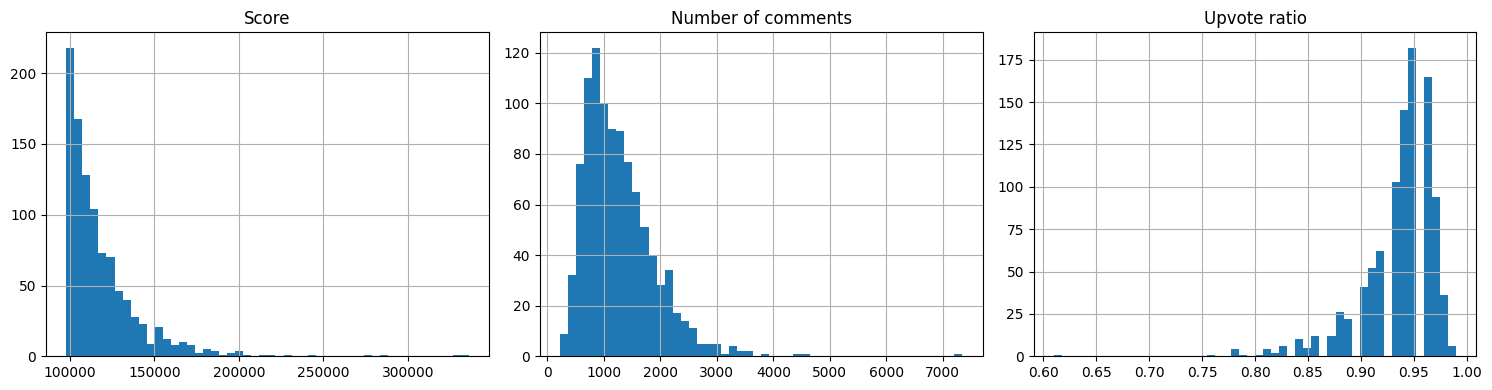

In [10]:
# Visualize distributions of potential engagement metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

aww_df['score'].hist(ax=axes[0], bins=50)
axes[0].set_title('Score')

aww_df['num_comments'].hist(ax=axes[1], bins=50)
axes[1].set_title('Number of comments')

aww_df['upvote_ratio'].hist(ax=axes[2], bins=50)
axes[2].set_title('Upvote ratio')

plt.tight_layout()
plt.show()

In [11]:
# Check standard deviation of upvote ratio to understand variability
aww_df['upvote_ratio'].std()

np.float64(0.03546152814755159)

#### 🙋‍♀️ Excluding Upvote Ratio

Upvote ratio captures how positively a post was received, but in this dataset it shows limited variation (standard deviation ≈ 0.035, with most values above 0.9). As a result, incorporating it into the engagement metric would have minimal impact on post ranking. It is therefore excluded from the initial engagement definition.

## Defining a first performance label

To create a simple performance target, score and number of comments are combined into a single engagement metric. This treats both visible popularity (`score`) and audience interaction (`num_comments`) as signals of content performance.

```
engagement = score + num_comments
```

In [12]:
aww_df['engagement'] =  aww_df['score'] + aww_df['num_comments']
aww_df['engagement'].describe()

count       993.000000
mean     119767.140987
std       24012.021528
min       98416.000000
25%      104484.000000
50%      112758.000000
75%      126583.000000
max      340330.000000
Name: engagement, dtype: float64

In [13]:
# Explore correlations between key metrics
aww_df[['score', 'num_comments','engagement']].corr()

,score,num_comments,engagement
score,1.000000,0.486849,0.999734
num_comments,0.486849,1.000000,0.506853
engagement,0.999734,0.506853,1.000000


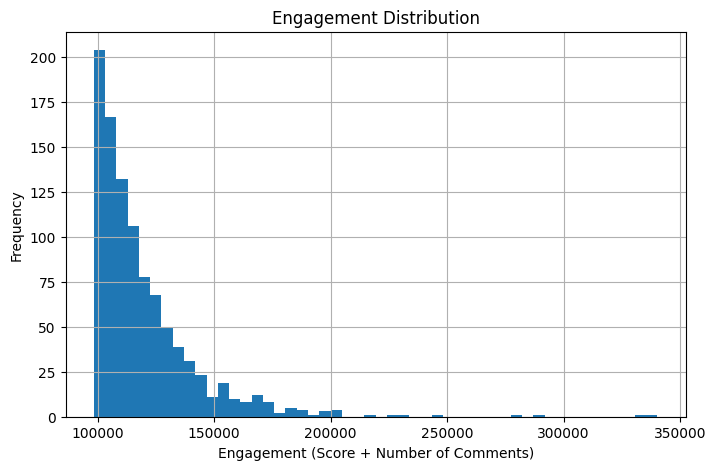

In [14]:
# Visualize engagement distribution
plt.figure(figsize=(8, 5))
aww_df['engagement'].hist(bins=50)
plt.title('Engagement Distribution')
plt.xlabel('Engagement (Score + Number of Comments)')
plt.ylabel('Frequency')
plt.show()

#### 🙋‍♀️ Engagement ~ Score

The correlation matrix and distributions demonstrate that the raw engagement metric (`score + num_comments`) is almost perfectly correlated with `score` due to its much larger scale than comment count. 

To ensure both contribute to an engagement measure meaningfully, both variables were standardised before combining them, so that each reflects relative performance within the dataset. 

**Standard scaling** was chosen over min-max scaling because the distributions are skewed with a long tail of high-scoring posts; scaling relative to the mean preserves variation among typical posts, rather than compressing them into a narrow range (as with min-max).

In [15]:
# Scale engagement metrics for better comparison
scaler = StandardScaler()

aww_df[['score_scaled', 'comments_scaled']] = scaler.fit_transform(
    aww_df[['score', 'num_comments']]
)

aww_df['engagement_v2'] = aww_df['score_scaled'] + aww_df['comments_scaled']

In [16]:
# Explore correlations between scaled metrics
aww_df[['score', 'num_comments', 'engagement', 'engagement_v2']].corr()

,score,num_comments,engagement,engagement_v2
score,1.000000,0.486849,0.999734,0.862221
num_comments,0.486849,1.000000,0.506853,0.862221
engagement,0.999734,0.506853,1.000000,0.873667
engagement_v2,0.862221,0.862221,0.873667,1.000000


<Axes: >

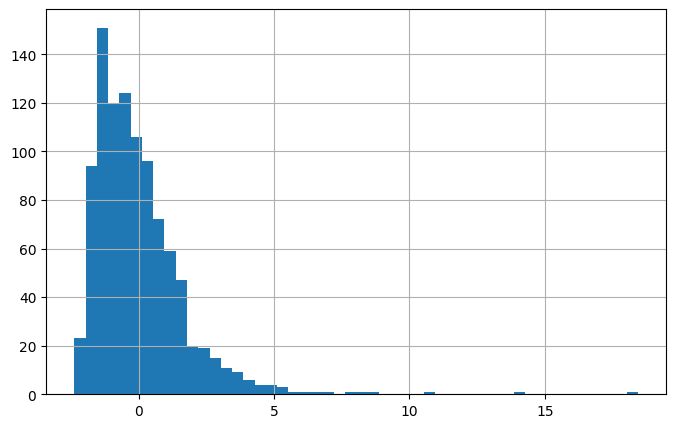

In [17]:
# Plot new enagagement distribution
plt.figure(figsize=(8, 5))
aww_df['engagement_v2'].hist(bins=50)

After scaling, the engagement metric is no longer as strongly correlated with score and instead shows a similar relationship with both score and comment count (correlation ≈ 0.86 with each). This indicates that both components now contribute to the metric, so this `engagement_v2` version is used as an engagement proxy going forward.

### Continous Variable ➡️ Binary Label

Engagement is highly skewed, with most posts clustered in a similar range and a small number of much higher values. 

Predicting exact engagement would mostly reflect noise in these differences, so here it is converted into a binary label using the top quartile as a threshold. 

This focuses the problem on separating higher-performing posts from the rest, which is more realistic given the size and quality of the data.

In [22]:
# Define high engagement as above 75th percentile of engagement_v2
threshold = aww_df['engagement_v2'].quantile(0.75)

aww_df['high_engagement'] = (aww_df['engagement_v2'] >= threshold).astype(int)
aww_df['high_engagement'].value_counts(normalize=True)

high_engagement
0    0.749245
1    0.250755
Name: proportion, dtype: float64

👉 Using the 75th percentile as a threshold results in approximately a 75/25 split between low and high engagement posts. 

This provides a clear separation while retaining enough examples of higher-performing content for modelling.

## 4. Validating Performance Signal

With a performance label defined, a simple baseline model is used to test whether post titles contain any signal related to engagement. The goal here is not to optimise performance, but to establish whether this problem is learnable from the available data.

Titles are converted into numerical features using TF-IDF, which represents each post based on the words it contains, while reducing the influence of very common words. This allows a simple classifier to test whether certain words or phrases are associated with higher engagement.

In [25]:
# Define features and target for modelling
X = aww_df["title"]
y = aww_df["high_engagement"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y       # maintain class balance in splits
)

# Convert text data to numerical features using TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)

# Learn vocabulary from training data and transform both training and test data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

# Predict on test set and evaluate
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86       149
           1       0.00      0.00      0.00        50

    accuracy                           0.75       199
   macro avg       0.37      0.50      0.43       199
weighted avg       0.56      0.75      0.64       199

[[149   0]
 [ 50   0]]


/Users/keira/.pyenv/versions/3.12.9/envs/content-intel-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keira/.pyenv/versions/3.12.9/envs/content-intel-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keira/.pyenv/versions/3.12.9/envs/content-intel-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

### 🧪 Baseline model performance

The baseline model predicts only the majority class (i.e. low engagement content), resulting in 75% accuracy but **zero recall for high-engagement posts**. 

This indicates that the model is not able to identify high-performing content from titles alone. 

In this subreddit at least, engagement appears to be weakly related to the text, or dominated by factors not captured in the title.

## EDA: Conclusion & Next Steps

The dataset is clean and suitable for modelling, with post titles providing a usable text input. Engagement is highly skewed and required careful definition; a scaled combination of score and comment count was used to ensure both signals contributed.

Converting engagement into a binary label produced a stable and learnable target. However, **a baseline model using titles alone was unable to identify high-engagement posts**, defaulting to the majority class. This suggests that engagement is either weakly related to the title or driven by factors not captured in this dataset.

In addition, suitability and category could not be meaningfully explored due to the use of a single subreddit with no variation in safety labels.

👉 Next steps:

- Expand the dataset to include multiple subreddits with varied topics and safety profiles
- Revisit suitability and category label definitions with this broader data
- Re-run baseline models to assess whether increased variation improves signal in the text